# LPJ-GUESS JJA-mean FPC workflow

This notebook validates the historical and future monthly FPC/LAI climatologies, reproduces the period summaries and Arctic plots, and writes June–July–August FPC means in the same schema and coordinate order as the supplied annual-mean files. The CLM surfdata conversion is intentionally omitted.

The two JJA files keep the annual filenames inside `LPJ-GUESS/JJA-mean/`, so downstream code can use them by changing the input directory only. `Total` is averaged from the monthly `Total` field; it is not reconstructed from the PFT columns.

## 1 · Configuration

In [9]:
from pathlib import Path
import re
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 12,
})

REPO_DIR = Path.home() / "BOREAL-FOREST-EXPANSION"
DATA_DIR = REPO_DIR / "data/edit-surfdata/LPJ-GUESS"
JJA_DIR = DATA_DIR / "JJA-mean"
FIGURE_DIR = Path("fpc-to-pft-processing-figures")

FPC_FUTURE = DATA_DIR / "mfpc_pft_avg_2070_2100_monthly_mean.out"
LAI_FUTURE = DATA_DIR / "mlai_pft_avg_2070_2100_monthly_mean.out"
FPC_HISTORICAL = DATA_DIR / "mfpc_pft_avg_1971_2000_monthly_mean.out"
LAI_HISTORICAL = DATA_DIR / "mlai_pft_avg_1971_2000_monthly_mean.out"
FPC_ANNUAL_FUTURE = DATA_DIR / "GFDL-ESM4_SSP585_fpc2071to2100.txt"
FPC_ANNUAL_HISTORICAL = DATA_DIR / "fpc1971to2000.txt"
REFERENCE_GRID = DATA_DIR / "gridlist45N_tundraboreal.txt"

# Same basenames as the annual files, but safely written in JJA-mean/.
# Downstream code can therefore switch from annual to JJA input by changing only the directory.
FPC_JJA_FUTURE = JJA_DIR / FPC_ANNUAL_FUTURE.name
FPC_JJA_HISTORICAL = JJA_DIR / FPC_ANNUAL_HISTORICAL.name

LPJ_NATURAL = [
    "BNE", "BINE", "BNS", "TeNE", "TeBE", "IBS", "TeBS", "C3G",
    "HSE", "HSS", "LSE", "LSS", "GRT", "EPDS", "SPDS", "CLM",
]

GROUPS = {
    "BoNET": ["BNE", "BINE"],
    "BoNDT (larch)": ["BNS"],
    "BoBDT": ["IBS"],
    "BoBDS shrubs": ["HSE", "HSS", "LSE", "LSS", "EPDS", "SPDS"],
    "aC3": ["C3G", "GRT"],
    "temperate trees": ["TeNE", "TeBE", "TeBS"],
}

GROUP_COLORS = {
    "BoNET": "#145A32",
    "BoNDT (larch)": "#E67E22",
    "BoBDT": "#6B8E23",
    "BoBDS shrubs": "#D4A017",
    "aC3": "#8B5A2B",
    "temperate trees": "teal",
}

MIN_DFPC = 0.01
MIN_DLAI = 0.25
MAX_DFPC_DENS = 0.05
MAX_DFPC_PER_DLAI = 0.10
SATURATION_FPC = 0.50
DFPC_NOISE_TOL = 0.01
PEAK_MONTH_TOL = 1e-4


def safe_filename(text):
    return re.sub(r"[^A-Za-z0-9_-]+", "_", text.strip().lower()).strip("_") or "figure"


def save_figure(fig, stem, directory=FIGURE_DIR, formats=("png", "pdf")):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    stem = safe_filename(stem)
    saved = []
    for extension in formats:
        path = directory / f"{stem}.{extension}"
        options = {"bbox_inches": "tight", "facecolor": "white"}
        if extension.lower() == "png":
            options["dpi"] = 300
        fig.savefig(path, **options)
        saved.append(path)
    return saved


for label, path in {
    "future FPC": FPC_FUTURE,
    "future LAI": LAI_FUTURE,
    "historical FPC": FPC_HISTORICAL,
    "historical LAI": LAI_HISTORICAL,
    "future annual FPC template": FPC_ANNUAL_FUTURE,
    "historical annual FPC template": FPC_ANNUAL_HISTORICAL,
}.items():
    print(f"{label}: {path} ({'found' if path.exists() else 'MISSING'})")

future FPC: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/mfpc_pft_avg_2070_2100_monthly_mean.out (found)
future LAI: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/mlai_pft_avg_2070_2100_monthly_mean.out (found)
historical FPC: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/mfpc_pft_avg_1971_2000_monthly_mean.out (found)
historical LAI: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/mlai_pft_avg_1971_2000_monthly_mean.out (found)
future annual FPC template: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/GFDL-ESM4_SSP585_fpc2071to2100.txt (found)
historical annual FPC template: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/fpc1971to2000.txt (found)


## 2 · Load monthly climatologies and validate their grain

Each monthly file must contain one row per `(Lon, Lat, Month)`. Repeated header rows are removed before numeric conversion, and every retained grid cell must contain all 12 calendar months.

In [2]:
def load_monthly_field(path):
    if not path.exists():
        raise FileNotFoundError(path)

    frame = pd.read_csv(path, sep=r"\s+", low_memory=False)
    repeated_headers = frame["Lon"].astype(str).eq("Lon")
    frame = frame.loc[~repeated_headers].copy()

    required = {"Lon", "Lat", "Month", "Total", *LPJ_NATURAL}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{path}: missing columns {sorted(missing)}")

    for column in frame.columns:
        frame[column] = pd.to_numeric(frame[column], errors="raise")

    duplicate_count = int(frame.duplicated(["Lon", "Lat", "Month"]).sum())
    if duplicate_count:
        raise ValueError(f"{path}: {duplicate_count} duplicate Lon/Lat/Month rows")
    if set(frame["Month"].unique()) != set(range(1, 13)):
        raise ValueError(f"{path}: expected calendar months 1–12")

    month_counts = frame.groupby(["Lon", "Lat"])["Month"].nunique()
    incomplete_cells = int((month_counts != 12).sum())
    if incomplete_cells:
        raise ValueError(f"{path}: {incomplete_cells} grid cells do not contain all 12 months")

    pft_columns = [column for column in frame.columns if column not in {"Lon", "Lat", "Month", "Total"}]
    total_residual = frame["Total"] - frame[pft_columns].sum(axis=1)

    indexed = frame.set_index(["Month", "Lat", "Lon"])
    pft = indexed[pft_columns].to_xarray().to_array("pft")
    pft = pft.transpose("pft", "Month", "Lat", "Lon").rename({"Month": "month", "Lat": "lat", "Lon": "lon"})
    total = indexed["Total"].to_xarray().rename({"Month": "month", "Lat": "lat", "Lon": "lon"})

    report = {
        "file": path.name,
        "rows": len(frame),
        "grid cells": frame[["Lon", "Lat"]].drop_duplicates().shape[0],
        "repeated headers removed": int(repeated_headers.sum()),
        "duplicate keys": duplicate_count,
        "incomplete cells": incomplete_cells,
        "total residual mean abs": float(total_residual.abs().mean()),
        "total residual max abs": float(total_residual.abs().max()),
    }
    return pft, total, report


future_fpc, future_fpc_total, fpc_future_report = load_monthly_field(FPC_FUTURE)
future_lai, future_lai_total, lai_future_report = load_monthly_field(LAI_FUTURE)
historical_fpc, historical_fpc_total, fpc_historical_report = load_monthly_field(FPC_HISTORICAL)
historical_lai, historical_lai_total, lai_historical_report = load_monthly_field(LAI_HISTORICAL)

future_fpc, future_lai = xr.align(future_fpc, future_lai, join="exact")
historical_fpc, historical_lai = xr.align(historical_fpc, historical_lai, join="exact")
historical_fpc, historical_lai, future_fpc, future_lai = xr.align(
    historical_fpc, historical_lai, future_fpc, future_lai, join="exact"
)

quality_report = pd.DataFrame([
    fpc_historical_report, lai_historical_report, fpc_future_report, lai_future_report,
])
display(quality_report.round(6))

if quality_report["total residual max abs"].max() > 1e-5:
    print(
        "NOTE: Total is not the simple sum of PFT columns. This is expected if Total applies "
        "natural/peatland land-cover fractions; grouped-PFT calculations do not use Total."
    )


,file,rows,grid cells,repeated headers removed,duplicate keys,incomplete cells,total residual mean abs,total residual max abs
0,mfpc_pft_avg_1971_2000_monthly_mean.out,200568,16714,0,0,0,0.099935,0.907504
1,mlai_pft_avg_1971_2000_monthly_mean.out,200568,16714,0,0,0,0.340991,3.247252
2,mfpc_pft_avg_2070_2100_monthly_mean.out,199428,16619,1,0,0,0.135690,0.985852
3,mlai_pft_avg_2070_2100_monthly_mean.out,199428,16619,1,0,0,0.501226,4.228732


NOTE: Total is not the simple sum of PFT columns. This is expected if Total applies natural/peatland land-cover fractions; grouped-PFT calculations do not use Total.


## 3 · Spatial coverage and common analysis grid

In [3]:
def valid_cell_mask(fpc, lai):
    return np.isfinite(fpc).any(("pft", "month")) & np.isfinite(lai).any(("pft", "month"))


historical_support = valid_cell_mask(historical_fpc, historical_lai)
future_support = valid_cell_mask(future_fpc, future_lai)
common_support = historical_support & future_support

coverage = pd.Series({
    "historical valid monthly cells": int(historical_support.sum()),
    "future valid monthly cells": int(future_support.sum()),
    "common valid cells": int(common_support.sum()),
    "historical-only monthly cells": int((historical_support & ~future_support).sum()),
    "future-only monthly cells": int((future_support & ~historical_support).sum()),
}, name="grid cells")
display(coverage.to_frame())

def coordinate_index_from_file(path, header=True):
    frame = pd.read_csv(path, sep=r"\s+", usecols=[0, 1], header=0 if header else None, dtype=str)
    frame.columns = ["lon", "lat"]
    frame["lon"] = pd.to_numeric(frame["lon"], errors="coerce")
    frame["lat"] = pd.to_numeric(frame["lat"], errors="coerce")
    frame = frame.dropna().round(2).drop_duplicates()
    return pd.MultiIndex.from_frame(frame[["lon", "lat"]], names=["lon", "lat"])


if REFERENCE_GRID.exists():
    reference_cells = coordinate_index_from_file(REFERENCE_GRID, header=False)
    grid_sets = {
        "reference grid": reference_cells,
        "historical annual": coordinate_index_from_file(FPC_ANNUAL_HISTORICAL),
        "future annual": coordinate_index_from_file(FPC_ANNUAL_FUTURE),
        "historical monthly": coordinate_index_from_file(FPC_HISTORICAL),
        "future monthly": coordinate_index_from_file(FPC_FUTURE),
    }
    grid_coverage = pd.DataFrame([
        {
            "dataset": name,
            "unique cells": len(index),
            "missing from reference": len(reference_cells.difference(index)),
            "outside reference": len(index.difference(reference_cells)),
        }
        for name, index in grid_sets.items()
    ]).set_index("dataset")
    display(grid_coverage)

historical_fpc_common = historical_fpc.where(common_support)
historical_lai_common = historical_lai.where(common_support)
future_fpc_common = future_fpc.where(common_support)
future_lai_common = future_lai.where(common_support)

print("All period summaries and historical–future anomalies below use the common valid grid.")


,grid cells
historical valid monthly cells,16714
future valid monthly cells,16619
common valid cells,16619
historical-only monthly cells,95
future-only monthly cells,0


,unique cells,missing from reference,outside reference
dataset,,,
reference grid,16750,0,0
historical annual,16750,0,0
future annual,16750,0,0
historical monthly,16714,36,0
future monthly,16619,131,0


All period summaries and historical–future anomalies below use the common valid grid.


## 4 · Aggregate PFTs and calculate annual, JJA, and peak fields

In [6]:
def aggregate_to_clm_groups(field):
    grouped = []
    for group, pfts in GROUPS.items():
        missing = set(pfts).difference(field.pft.values.tolist())
        if missing:
            raise ValueError(f"{group}: missing LPJ PFTs {sorted(missing)}")
        grouped.append(field.sel(pft=pfts).sum("pft", skipna=False))
    return xr.concat(grouped, dim=pd.Index(GROUPS, name="group"))


def peak_period_fields(grouped_fpc, grouped_lai):
    grouped_fpc, grouped_lai = xr.align(grouped_fpc, grouped_lai, join="exact")
    valid = np.isfinite(grouped_fpc).any("month") & np.isfinite(grouped_lai).any("month")

    peak_index = grouped_fpc.fillna(-np.inf).argmax("month")
    peak_fpc = grouped_fpc.max("month", skipna=True).where(valid)
    lai_at_fpc_peak = grouped_lai.isel(month=peak_index).reset_coords("month", drop=True).where(valid)
    peak_month = (peak_index + 1).astype(float).where(valid)

    return xr.Dataset({
        "peak_fpc": peak_fpc,
        "lai_at_fpc_peak": lai_at_fpc_peak,
        "peak_month": peak_month,
        "annual_mean_fpc": grouped_fpc.mean("month", skipna=True).where(valid),
        "jja_mean_fpc": grouped_fpc.sel(month=[6, 7, 8]).mean("month", skipna=True).where(valid),
    })


historical_fpc_grouped = aggregate_to_clm_groups(historical_fpc_common)
historical_lai_grouped = aggregate_to_clm_groups(historical_lai_common)
future_fpc_grouped = aggregate_to_clm_groups(future_fpc_common)
future_lai_grouped = aggregate_to_clm_groups(future_lai_common)

historical_peak = peak_period_fields(historical_fpc_grouped, historical_lai_grouped)
future_peak = peak_period_fields(future_fpc_grouped, future_lai_grouped)

AREA_WEIGHT = xr.DataArray(
    np.cos(np.deg2rad(future_peak.lat)), coords={"lat": future_peak.lat}, dims="lat", name="coslat"
).broadcast_like(future_peak.peak_fpc.isel(group=0))


def weighted_sum(values, mask=None):
    if mask is None:
        mask = np.isfinite(values)
    return float((values.where(mask) * AREA_WEIGHT).sum(skipna=True))


def weighted_mean(values, mask=None):
    if mask is None:
        mask = np.isfinite(values)
    valid = mask & np.isfinite(values)
    weights = AREA_WEIGHT.where(valid)
    denominator = float(weights.sum(skipna=True))
    return float((values.where(valid) * weights).sum(skipna=True)) / denominator if denominator > 0 else np.nan


def spatial_mean_peak_month(group_seasonal, tolerance=PEAK_MONTH_TOL):
    values = group_seasonal.values
    finite = np.isfinite(values)
    if not finite.any():
        return np.nan
    maximum = np.nanmax(values)
    candidates = group_seasonal.month.values[np.isclose(values, maximum, atol=tolerance, rtol=0)]
    return int(candidates[0]) if len(candidates) == 1 else np.nan


## 5 · Historical and future summary tables

In [7]:
def period_summary(period_peak, grouped_fpc):
    seasonal = grouped_fpc.weighted(AREA_WEIGHT).mean(("lat", "lon"))
    rows = []

    for group in period_peak.group.values:
        peak = period_peak.peak_fpc.sel(group=group)
        annual = period_peak.annual_mean_fpc.sel(group=group)
        jja = period_peak.jja_mean_fpc.sel(group=group)
        peak_mean = weighted_mean(peak)
        annual_mean = weighted_mean(annual)
        jja_mean = weighted_mean(jja)
        peak_month = spatial_mean_peak_month(seasonal.sel(group=group))

        rows.append({
            "group": group,
            "annual mean FPC": annual_mean,
            "JJA mean FPC": jja_mean,
            "cellwise peak FPC": peak_mean,
            "spatial-mean peak month": peak_month,
            "annual mean / peak": annual_mean / peak_mean if peak_mean > 0 else np.nan,
            "JJA mean / peak": jja_mean / peak_mean if peak_mean > 0 else np.nan,
            "peak uplift over annual mean %": 100 * (peak_mean / annual_mean - 1) if annual_mean > 0 else np.nan,
        })

    return pd.DataFrame(rows).set_index("group"), seasonal


historical_peak_comparison, historical_seasonal = period_summary(historical_peak, historical_fpc_grouped)
future_peak_comparison, future_seasonal = period_summary(future_peak, future_fpc_grouped)

print("Historical 1971–2000 (common grid)")
display(historical_peak_comparison.round(3))
print("Future 2071–2100 (common grid)")
display(future_peak_comparison.round(3))


Historical 1971–2000 (common grid)


,annual mean FPC,JJA mean FPC,cellwise peak FPC,spatial-mean peak month,annual mean / peak,JJA mean / peak,peak uplift over annual mean %
group,,,,,,,
BoNET,0.227,0.227,0.227,NaN,1.000,1.000,0.010
BoNDT (larch),0.018,0.051,0.053,NaN,0.336,0.961,197.614
BoBDT,0.012,0.030,0.031,NaN,0.402,0.967,148.584
BoBDS shrubs,0.016,0.032,0.034,NaN,0.469,0.937,113.016
aC3,0.067,0.197,0.227,8.0,0.297,0.866,236.904
temperate trees,0.002,0.004,0.004,NaN,0.444,0.984,125.419


Future 2071–2100 (common grid)


,annual mean FPC,JJA mean FPC,cellwise peak FPC,spatial-mean peak month,annual mean / peak,JJA mean / peak,peak uplift over annual mean %
group,,,,,,,
BoNET,0.266,0.266,0.266,NaN,1.000,1.000,0.016
BoNDT (larch),0.048,0.122,0.124,NaN,0.386,0.987,158.804
BoBDT,0.052,0.111,0.113,NaN,0.458,0.985,118.353
BoBDS shrubs,0.020,0.044,0.046,NaN,0.444,0.953,125.383
aC3,0.045,0.114,0.125,8.0,0.364,0.914,175.035
temperate trees,0.008,0.014,0.014,NaN,0.538,0.997,85.844


## 6 · Historical and future seasonal-cycle figures

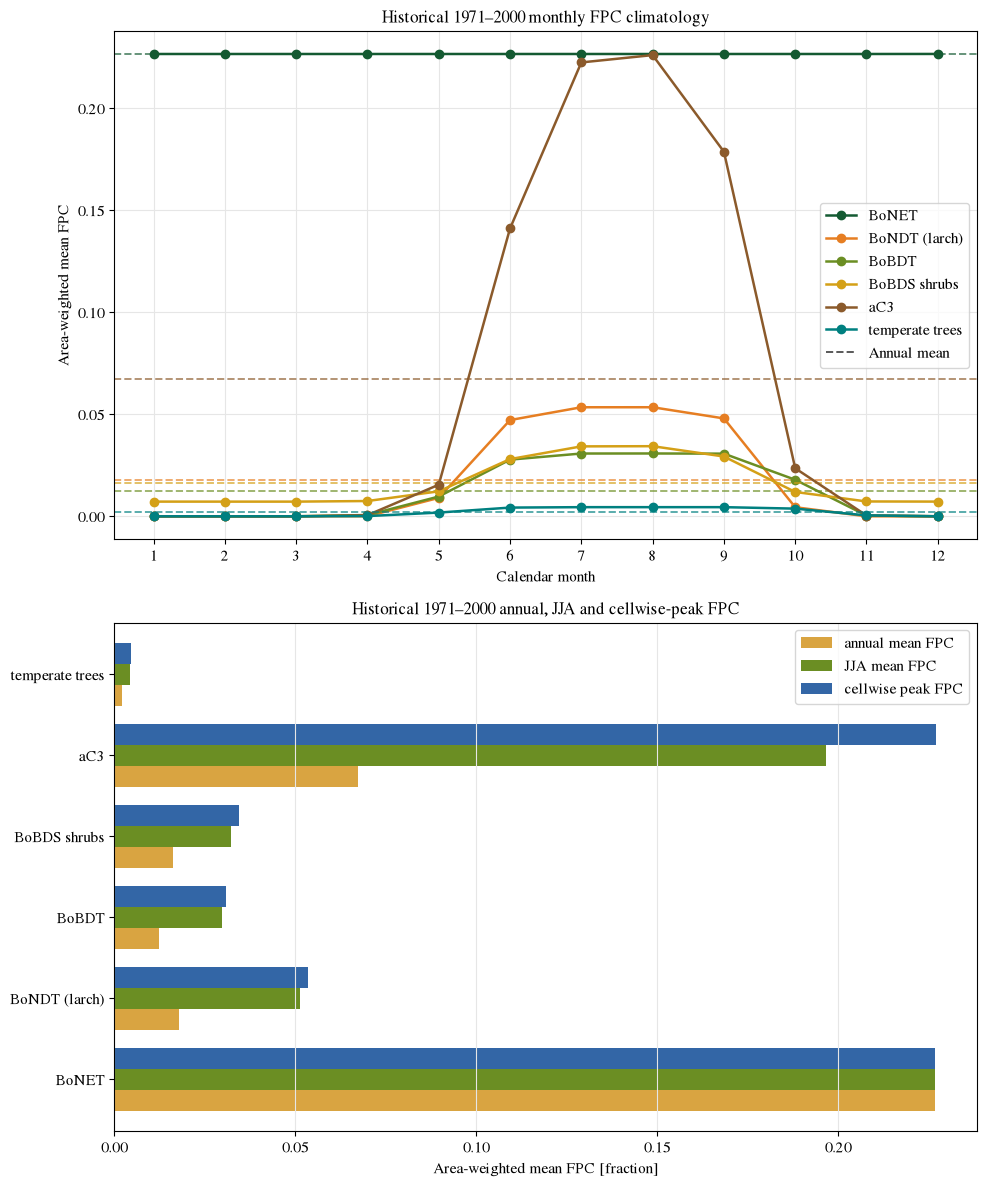

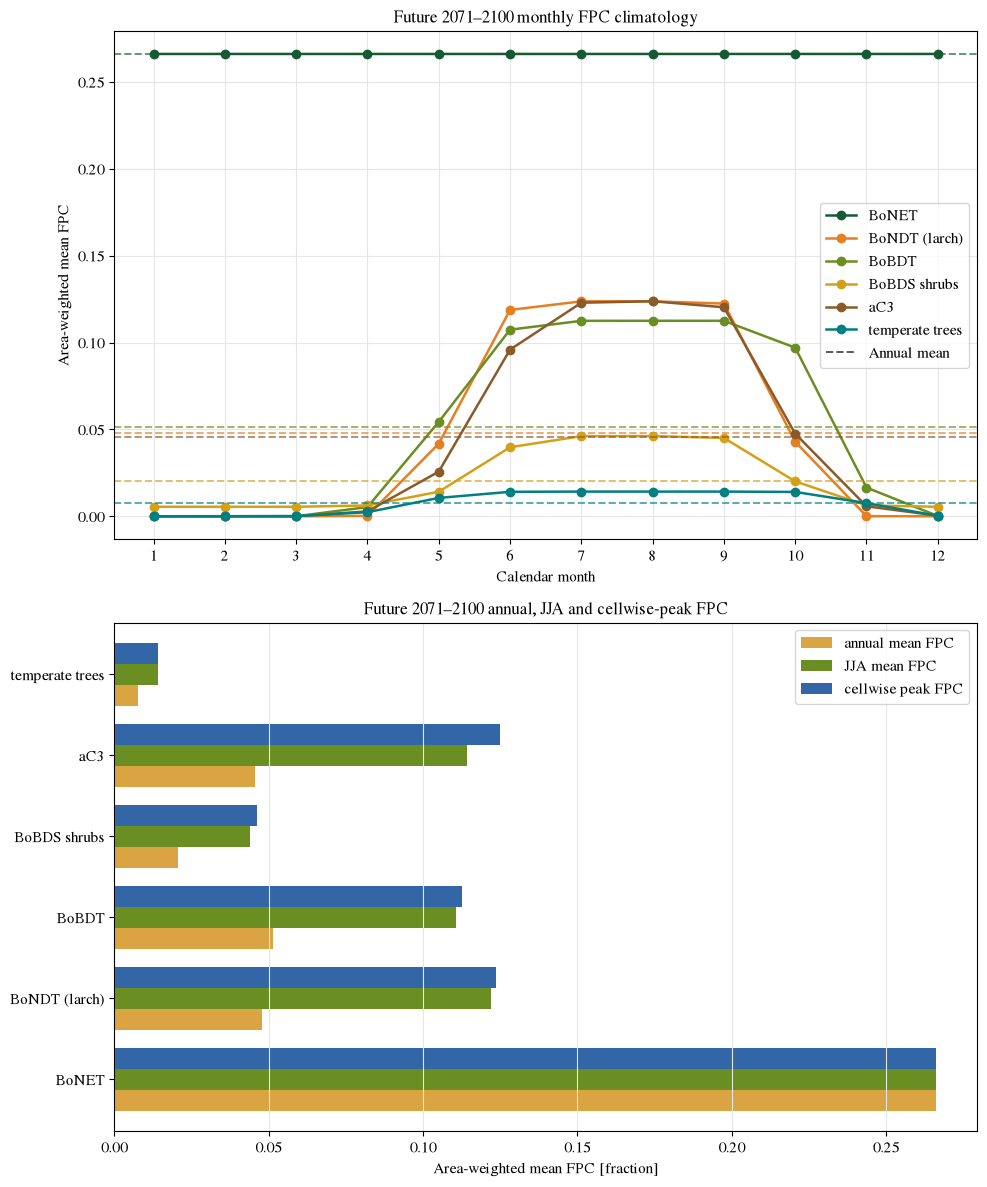

In [10]:
def plot_period_summary(period_label, seasonal, comparison):
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))

    for group in seasonal.group.values:
        group_name = str(group)
        group_seasonal = seasonal.sel(group=group)
        color = GROUP_COLORS[group_name]
        axes[0].plot(seasonal.month, group_seasonal, color=color, marker="o", linewidth=1.8, label=group_name)
        axes[0].axhline(float(group_seasonal.mean("month")), color=color, linestyle="--", linewidth=1.4, alpha=0.65)

    axes[0].set(
        title=f"{period_label} monthly FPC climatology", xlabel="Calendar month",
        ylabel="Area-weighted mean FPC", xticks=range(1, 13),
    )
    axes[0].grid(color="0.9")
    axes[0].set_axisbelow(True)
    handles, _ = axes[0].get_legend_handles_labels()
    handles.append(Line2D([0], [0], color="0.35", linestyle="--", linewidth=1.4, label="Annual mean"))
    axes[0].legend(handles=handles)

    comparison[["annual mean FPC", "JJA mean FPC", "cellwise peak FPC"]].plot.barh(
        ax=axes[1], color=["#D9A441", "#6B8E23", "#3366A6"], width=0.78,
    )
    axes[1].set(
        title=f"{period_label} annual, JJA and cellwise-peak FPC",
        xlabel="Area-weighted mean FPC [fraction]", ylabel="", xlim=(0, None),
    )
    axes[1].grid(axis="x", color="0.9")
    axes[1].legend()
    fig.tight_layout()
    save_figure(fig, f"{period_label}_seasonal_cycle_and_summary")
    plt.show()


plot_period_summary("Historical 1971–2000", historical_seasonal, historical_peak_comparison)
plot_period_summary("Future 2071–2100", future_seasonal, future_peak_comparison)


## 7 · Arctic maps for both periods

In [11]:
MAP_EXTENT = [-180, 180, 45, 90]
PRESENCE_THRESHOLD = 1e-6
SCALE_PERCENTILE = 99.5


def robust_upper(field, percentile=SCALE_PERCENTILE):
    values = field.values
    values = values[np.isfinite(values)]
    return max(float(np.percentile(values, percentile)), 1e-6)


def configure_arctic_axis(ax):
    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="0.94", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.coastlines(linewidth=0.5, color="0.25")
    ax.gridlines(crs=ccrs.PlateCarree(), linewidth=0.4, color="0.65", alpha=0.5, linestyle=":")
    theta = np.linspace(0, 2 * np.pi, 200)
    circle = np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5
    ax.set_boundary(mpath.Path(circle), transform=ax.transAxes)


def prepare_map_fields(period_peak):
    prepared = {}
    for group in period_peak.group.values:
        group_name = str(group)
        annual_raw = period_peak.annual_mean_fpc.sel(group=group)
        peak_raw = period_peak.peak_fpc.sel(group=group)
        active = np.isfinite(annual_raw) & np.isfinite(peak_raw) & (peak_raw > PRESENCE_THRESHOLD)
        overall_annual = weighted_mean(annual_raw)
        overall_peak = weighted_mean(peak_raw)
        prepared[group_name] = {
            "annual": annual_raw.where(active),
            "peak": peak_raw.where(active),
            "normalized_correction": ((peak_raw - annual_raw).clip(min=0) / overall_annual).where(active),
            "overall_relative_correction": 100 * (overall_peak - overall_annual) / overall_annual if overall_annual > 0 else np.nan,
        }
    return prepared


historical_map_fields = prepare_map_fields(historical_peak)
future_map_fields = prepare_map_fields(future_peak)

all_normalized_values = np.concatenate([
    fields["normalized_correction"].values[np.isfinite(fields["normalized_correction"].values)]
    for period_fields in [historical_map_fields, future_map_fields]
    for fields in period_fields.values()
])
NORMALIZED_VMAX = max(float(np.percentile(all_normalized_values, SCALE_PERCENTILE)), 1e-6)

absolute_upper_by_group = {
    group: robust_upper(xr.concat([
        historical_map_fields[group]["annual"], historical_map_fields[group]["peak"],
        future_map_fields[group]["annual"], future_map_fields[group]["peak"],
    ], dim="metric"))
    for group in GROUPS
}

print(f"Shared normalized-correction scale: 0–{NORMALIZED_VMAX:.3f} [fraction]")


Shared normalized-correction scale: 0–16.860 [fraction]


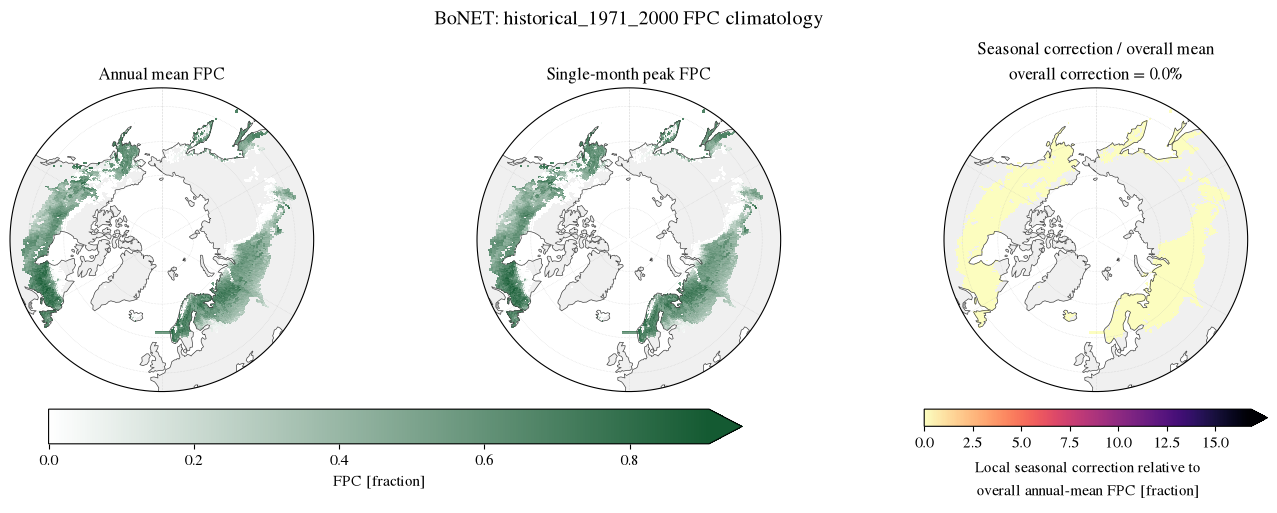

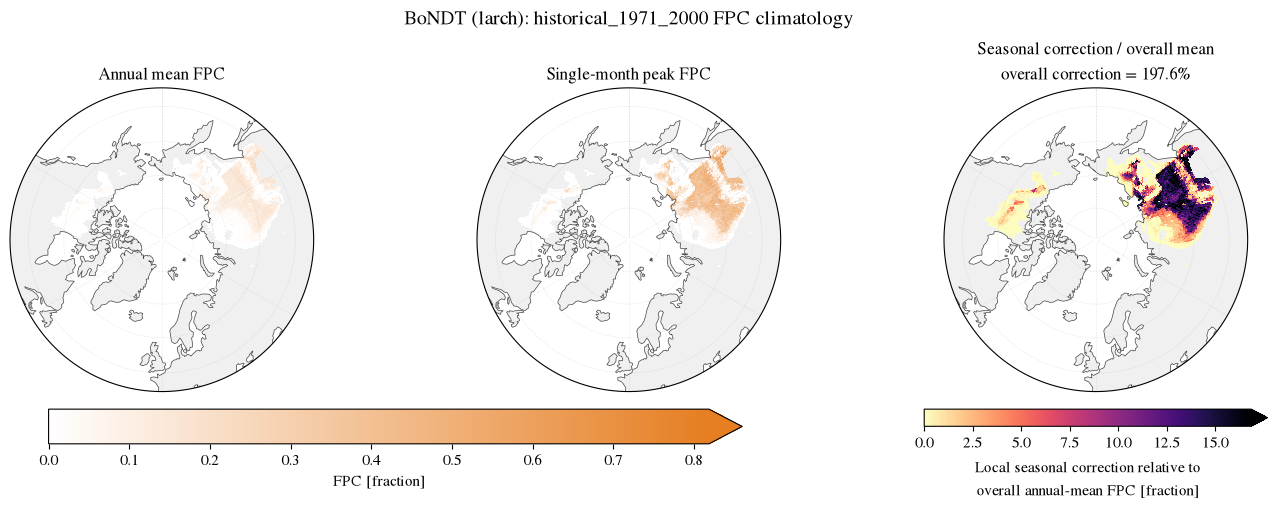

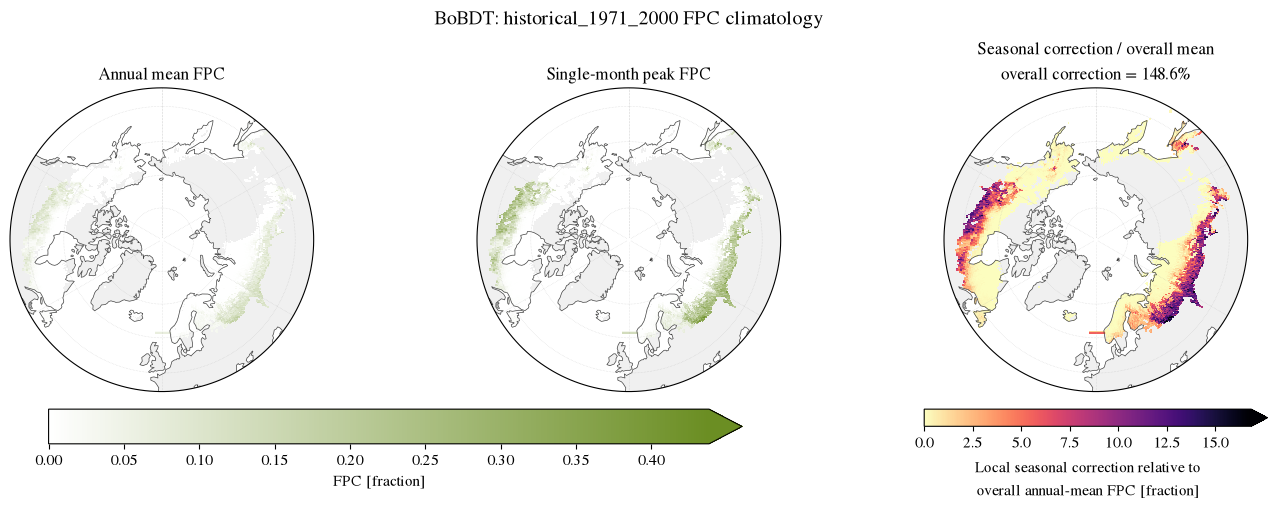

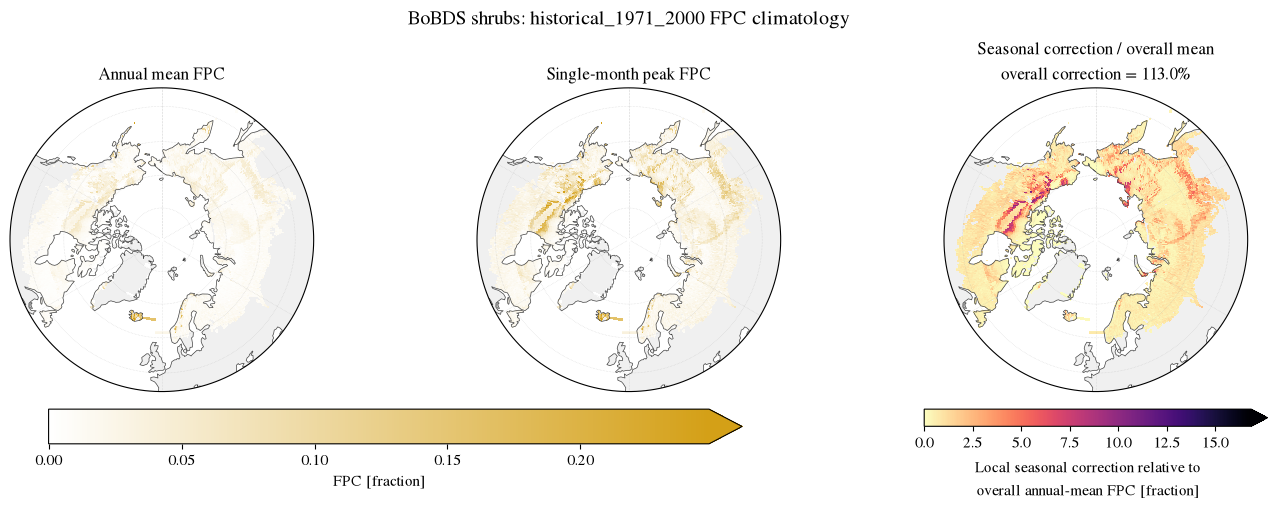

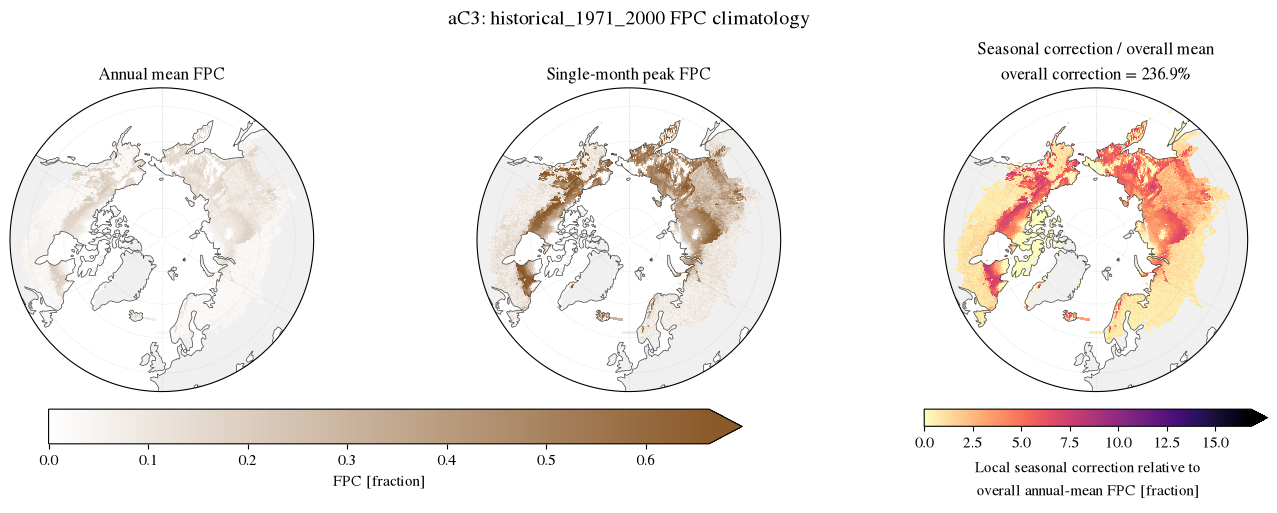

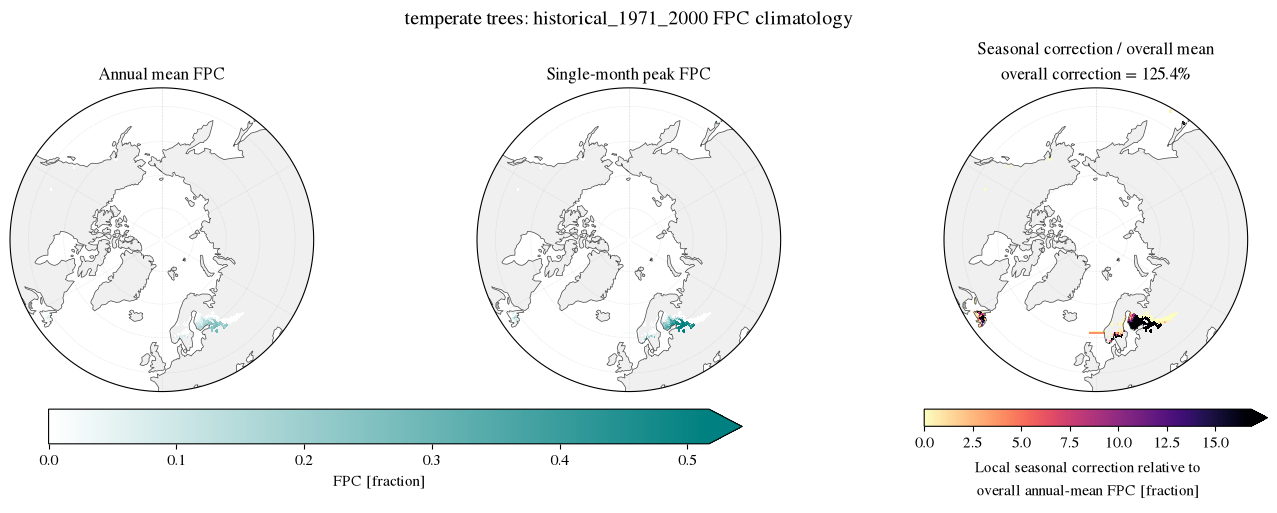

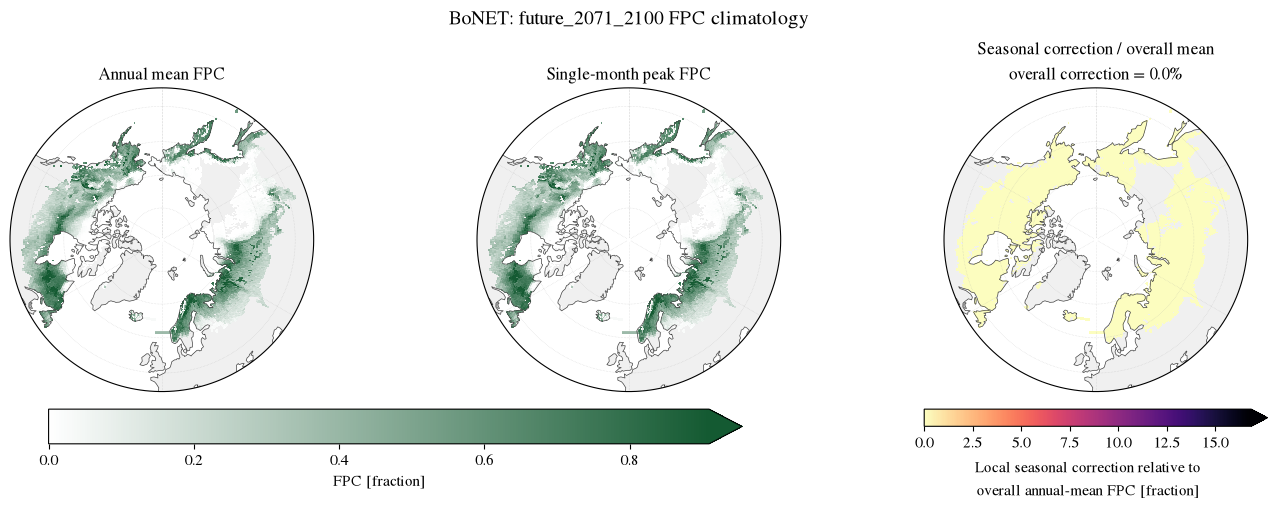

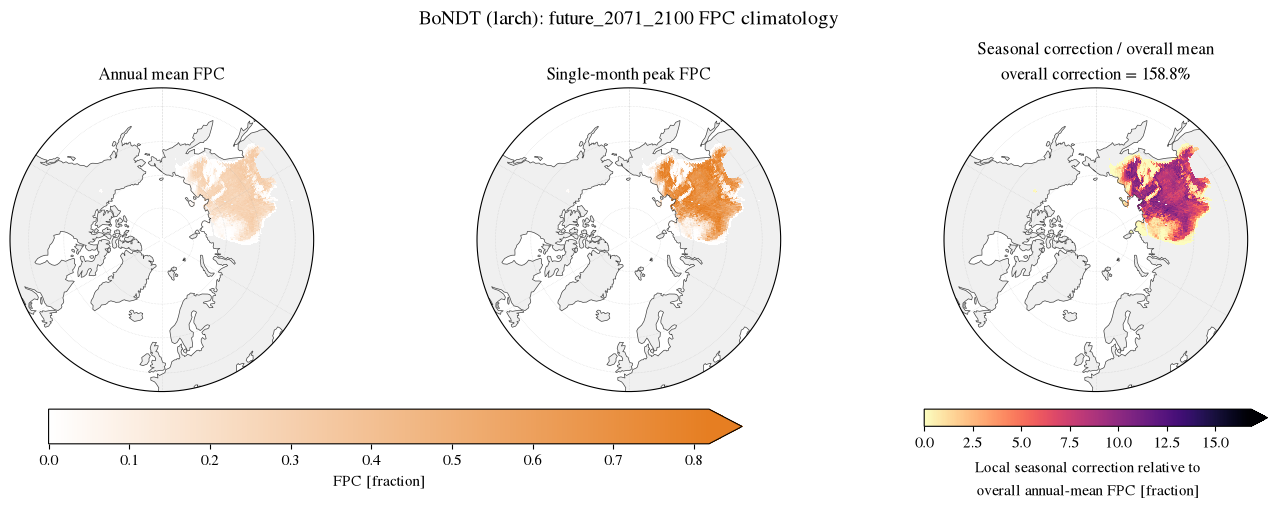

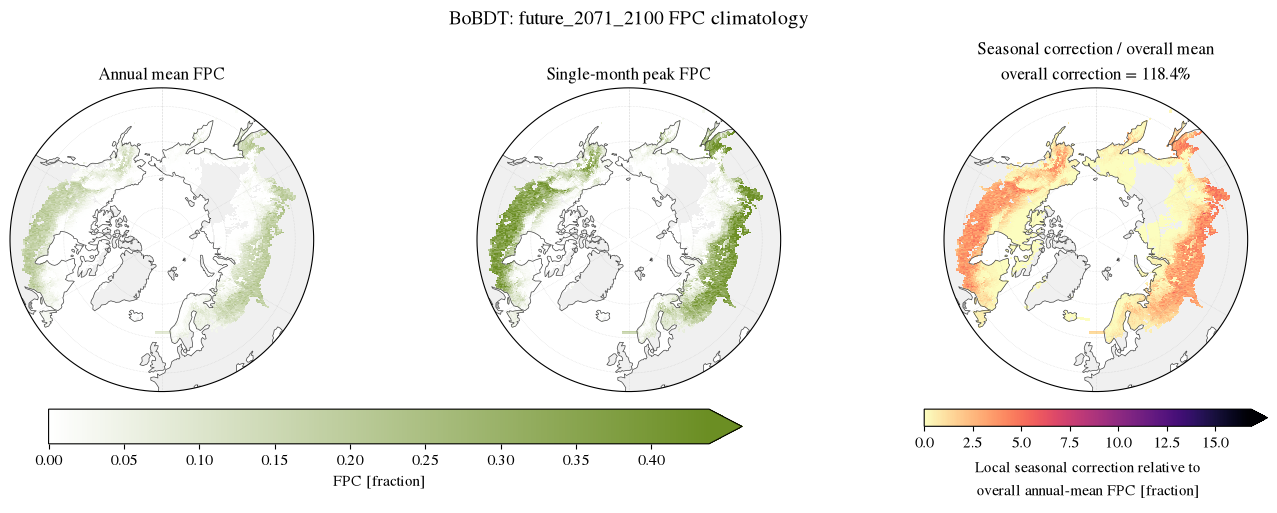

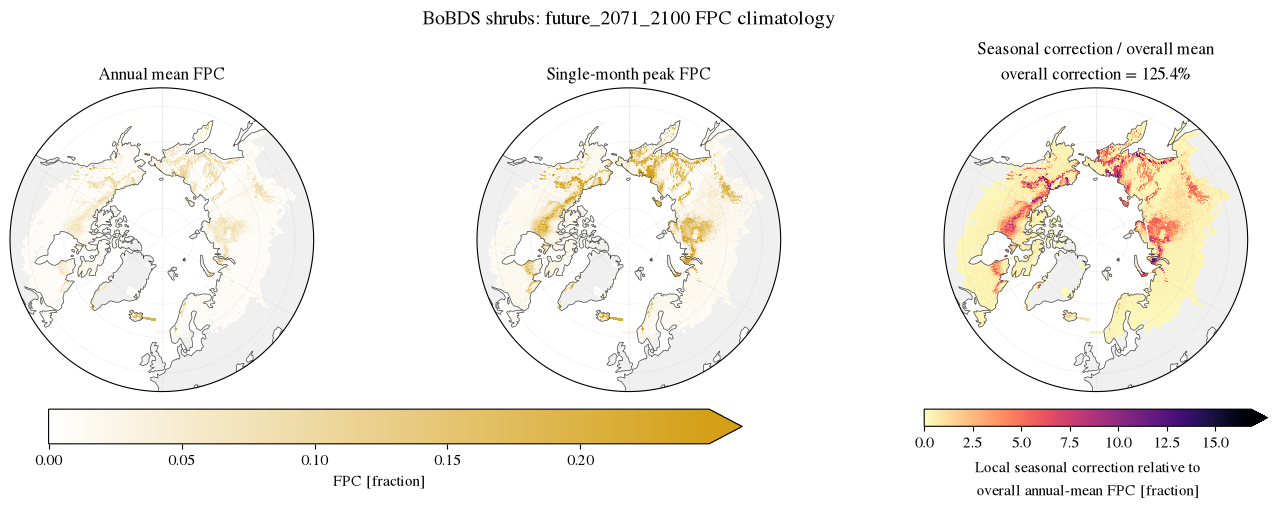

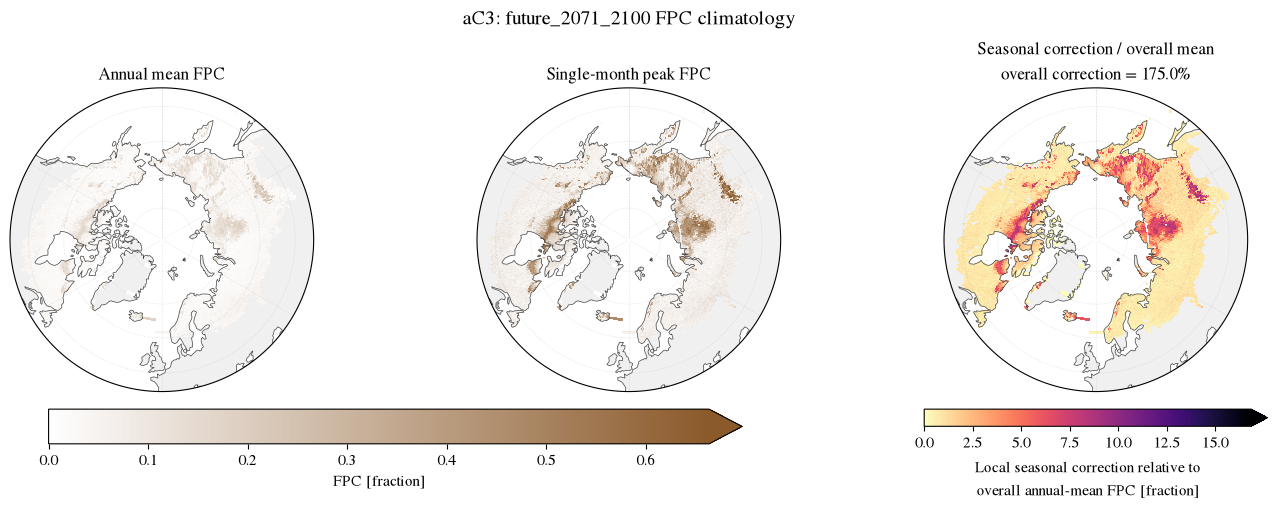

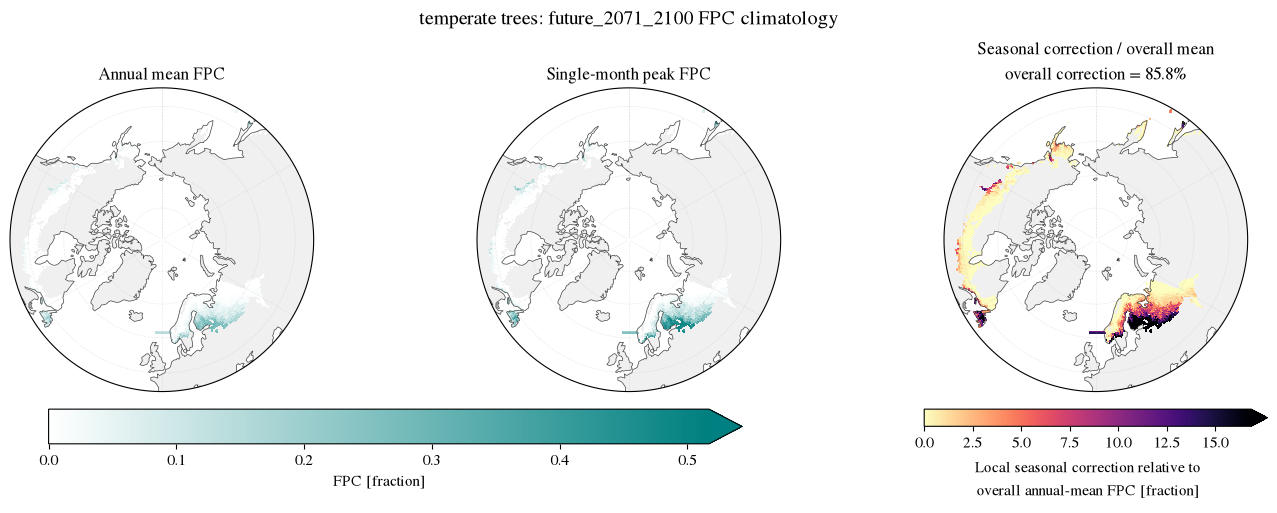

In [12]:
def plot_period_fpc_maps(period_label, period_fields):
    for group_name, fields in period_fields.items():
        absolute_norm = Normalize(vmin=0, vmax=absolute_upper_by_group[group_name])
        correction_norm = Normalize(vmin=0, vmax=NORMALIZED_VMAX)
        group_cmap = LinearSegmentedColormap.from_list(
            f"{safe_filename(group_name)}_fpc", ["#FFFFFF", GROUP_COLORS[group_name]]
        )

        projection = ccrs.NorthPolarStereo(central_longitude=0)
        fig, axes = plt.subplots(1, 3, figsize=(14, 5), subplot_kw={"projection": projection}, layout="constrained")
        plot_fields = [fields["annual"], fields["peak"], fields["normalized_correction"]]
        titles = [
            "Annual mean FPC", "Single-month peak FPC",
            "Seasonal correction / overall mean\n"
            f"overall correction = {fields['overall_relative_correction']:.1f}%",
        ]
        images = []

        for index, (ax, field, title) in enumerate(zip(axes, plot_fields, titles)):
            configure_arctic_axis(ax)
            image = ax.pcolormesh(
                field.lon, field.lat, field, transform=ccrs.PlateCarree(), shading="auto",
                cmap=group_cmap if index < 2 else "magma_r",
                norm=absolute_norm if index < 2 else correction_norm, rasterized=True,
            )
            ax.set_title(title)
            images.append(image)

        absolute_bar = fig.colorbar(images[0], ax=axes[:2], orientation="horizontal", shrink=0.75, pad=0.05, extend="max")
        absolute_bar.set_label("FPC [fraction]")
        correction_bar = fig.colorbar(images[2], ax=axes[2], orientation="horizontal", shrink=0.75, pad=0.05, extend="max")
        correction_bar.set_label("Local seasonal correction relative to\noverall annual-mean FPC [fraction]")
        fig.suptitle(f"{group_name}: {period_label} FPC climatology", fontsize=14)
        save_figure(fig, f"{period_label}_{group_name}_fpc_climatology")
        plt.show()


plot_period_fpc_maps("historical_1971_2000", historical_map_fields)
plot_period_fpc_maps("future_2071_2100", future_map_fields)


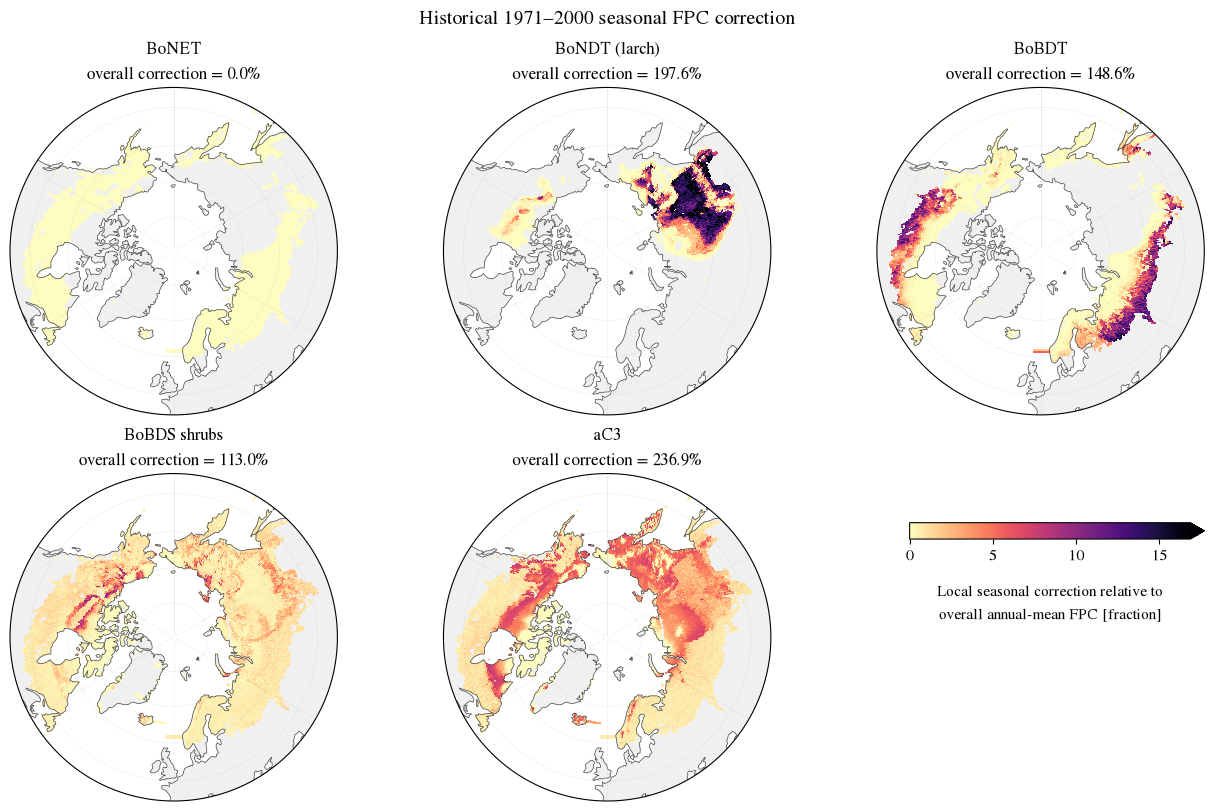

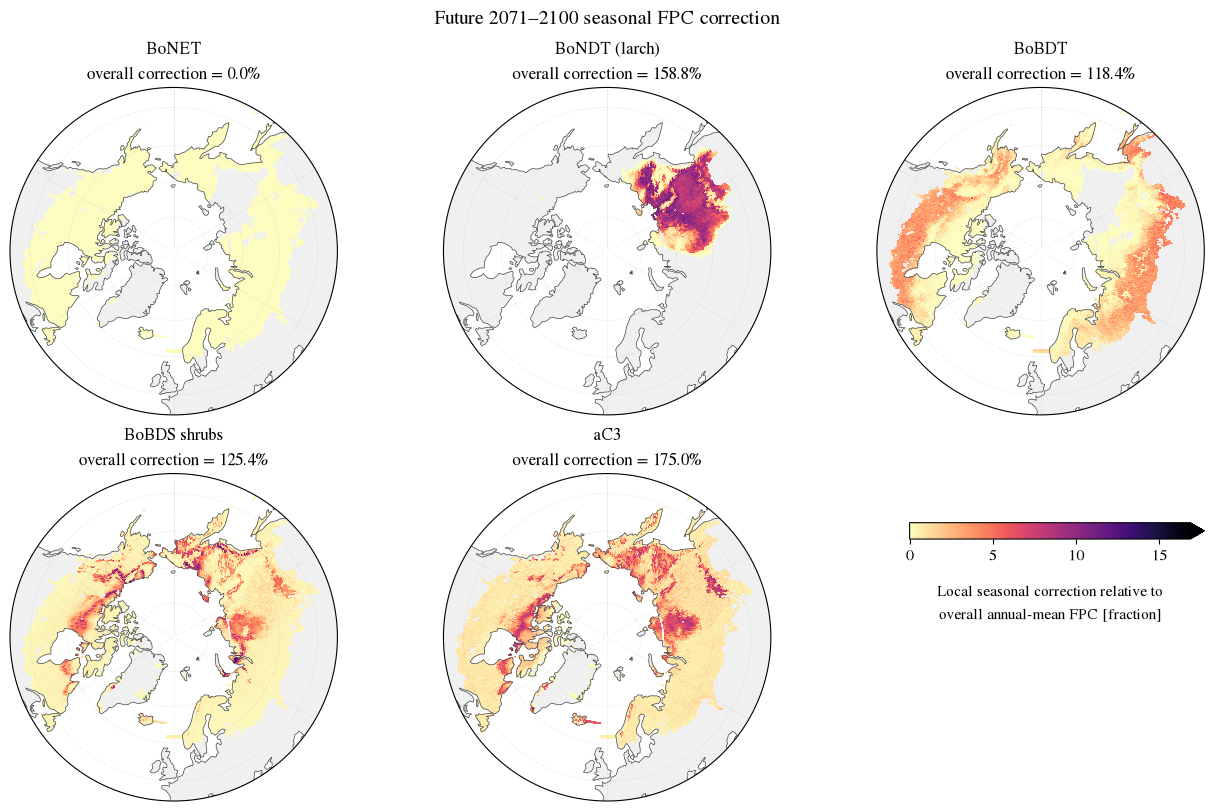

In [13]:
def plot_normalized_correction_summary(period_label, period_fields):
    projection = ccrs.NorthPolarStereo(central_longitude=0)
    fig, axes = plt.subplots(2, 3, figsize=(13, 8), subplot_kw={"projection": projection}, layout="constrained")
    axes = axes.ravel()
    correction_norm = Normalize(vmin=0, vmax=NORMALIZED_VMAX)
    image = None

    for ax, (group_name, fields) in zip(axes[:5], period_fields.items()):
        configure_arctic_axis(ax)
        image = ax.pcolormesh(
            fields["normalized_correction"].lon, fields["normalized_correction"].lat,
            fields["normalized_correction"], transform=ccrs.PlateCarree(), shading="auto",
            cmap="magma_r", norm=correction_norm, rasterized=True,
        )
        ax.set_title(f"{group_name}\noverall correction = {fields['overall_relative_correction']:.1f}%")

    colorbar_panel = axes[5]
    colorbar_panel.set_axis_off()
    colorbar_axis = colorbar_panel.inset_axes([0.1, 0.8, 0.9, 0.05])
    colorbar = fig.colorbar(image, cax=colorbar_axis, orientation="horizontal", extend="max")
    colorbar.set_label(
        "Local seasonal correction relative to\noverall annual-mean FPC [fraction]", labelpad=12
    )
    fig.suptitle(f"{period_label} seasonal FPC correction", fontsize=14)
    save_figure(fig, f"{period_label}_normalized_seasonal_fpc_correction")
    plt.show()


plot_normalized_correction_summary("Historical 1971–2000", historical_map_fields)
plot_normalized_correction_summary("Future 2071–2100", future_map_fields)


## 8 · Peak anomaly and expansion–densification diagnostic

The peak anomaly is the difference between period-specific climatological peaks, not the maximum of monthly future-minus-historical differences. This diagnostic is retained for comparison with the original workflow.

In [14]:
peak_change = xr.Dataset({
    "dFPC_peak": future_peak.peak_fpc - historical_peak.peak_fpc,
    "dLAI_at_FPC_peak": future_peak.lai_at_fpc_peak - historical_peak.lai_at_fpc_peak,
    "historical_peak_fpc": historical_peak.peak_fpc,
    "future_peak_fpc": future_peak.peak_fpc,
    "historical_peak_month": historical_peak.peak_month,
    "future_peak_month": future_peak.peak_month,
})

print("Peak anomaly constructed on", int(common_support.sum()), "common valid grid cells.")
print("Auxiliary month coordinate present:", "month" in peak_change.coords)


Peak anomaly constructed on 16619 common valid grid cells.
Auxiliary month coordinate present: False


In [15]:
def classify_peak_change(ds):
    fh = ds.historical_peak_fpc
    ff = ds.future_peak_fpc
    dF = ds.dFPC_peak
    dL = ds.dLAI_at_FPC_peak
    valid = np.isfinite(fh) & np.isfinite(ff) & np.isfinite(dF) & np.isfinite(dL)
    max_fpc = xr.concat([fh, ff], dim="period").max("period", skipna=False)
    response = xr.where(dL > 0, dF.clip(min=0) / dL, np.nan)

    densification = (
        valid & (dL >= MIN_DLAI) & (dF >= -DFPC_NOISE_TOL)
        & (dF <= MAX_DFPC_DENS) & (response <= MAX_DFPC_PER_DLAI)
        & (max_fpc >= SATURATION_FPC)
    )
    expansion = valid & (dF > MIN_DFPC) & ~densification
    other = valid & ~expansion & ~densification
    return ds.assign(response=response, valid=valid, expansion=expansion, densification=densification, other=other)


peak_diagnostic = classify_peak_change(peak_change)
rows = []

for group in peak_diagnostic.group.values:
    ds = peak_diagnostic.sel(group=group)
    positive_fpc = ds.valid & (ds.dFPC_peak > MIN_DFPC)
    material_lai = ds.valid & (ds.dLAI_at_FPC_peak >= MIN_DLAI)
    fpc_total = weighted_sum(ds.dFPC_peak, positive_fpc)
    lai_total = weighted_sum(ds.dLAI_at_FPC_peak, material_lai)

    rows.append({
        "group": group,
        "+dFPC: expansion %": 100 * weighted_sum(ds.dFPC_peak, positive_fpc & ds.expansion) / fpc_total if fpc_total > 0 else np.nan,
        "+dFPC: densification %": 100 * weighted_sum(ds.dFPC_peak, positive_fpc & ds.densification) / fpc_total if fpc_total > 0 else np.nan,
        "+dLAI: expansion %": 100 * weighted_sum(ds.dLAI_at_FPC_peak, material_lai & ds.expansion) / lai_total if lai_total > 0 else np.nan,
        "+dLAI: densification %": 100 * weighted_sum(ds.dLAI_at_FPC_peak, material_lai & ds.densification) / lai_total if lai_total > 0 else np.nan,
        "+dLAI: other %": 100 * weighted_sum(ds.dLAI_at_FPC_peak, material_lai & ds.other) / lai_total if lai_total > 0 else np.nan,
    })

diagnostic_summary = pd.DataFrame(rows).set_index("group")
display(diagnostic_summary.round(1))


,+dFPC: expansion %,+dFPC: densification %,+dLAI: expansion %,+dLAI: densification %,+dLAI: other %
group,,,,,
BoNET,99.6,0.4,96.6,2.0,1.4
BoNDT (larch),100.0,0.0,99.9,0.1,0.0
BoBDT,100.0,0.0,100.0,0.0,0.0
BoBDS shrubs,100.0,0.0,97.4,0.0,2.6
aC3,100.0,0.0,99.1,0.1,0.9
temperate trees,99.9,0.1,96.4,0.4,3.2


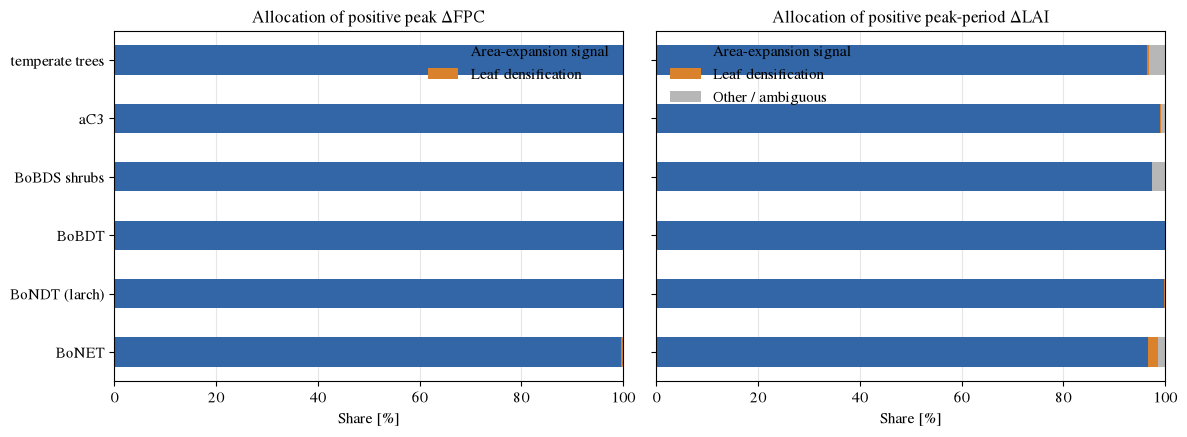

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

diagnostic_summary[["+dFPC: expansion %", "+dFPC: densification %"]].rename(columns={
    "+dFPC: expansion %": "Area-expansion signal", "+dFPC: densification %": "Leaf densification",
}).plot.barh(stacked=True, ax=axes[0], color=["#3366A6", "#D9822B"])
axes[0].set(title="Allocation of positive peak ΔFPC", xlabel="Share [%]", ylabel="", xlim=(0, 100))

diagnostic_summary[["+dLAI: expansion %", "+dLAI: densification %", "+dLAI: other %"]].rename(columns={
    "+dLAI: expansion %": "Area-expansion signal", "+dLAI: densification %": "Leaf densification",
    "+dLAI: other %": "Other / ambiguous",
}).plot.barh(stacked=True, ax=axes[1], color=["#3366A6", "#D9822B", "#B7B7B7"])
axes[1].set(title="Allocation of positive peak-period ΔLAI", xlabel="Share [%]", ylabel="", xlim=(0, 100))

for ax in axes:
    ax.grid(axis="x", color="0.9")
    ax.set_axisbelow(True)
    ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, "peak_expansion_densification_diagnostic")
plt.show()


## 9 · Write JJA means in annual-file form

The annual files are used strictly as templates for column order, coordinate coverage, and row order. The output values are the arithmetic mean of months 6, 7, and 8 from the monthly climatologies. The cell aborts rather than writing a partial or misaligned grid.

In [17]:
def read_numeric_whitespace_table(path):
    """Read a whitespace table, remove repeated headers, and convert all columns to numeric."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    frame = pd.read_csv(path, sep=r"\s+", dtype=str, low_memory=False)
    required_coordinates = {"Lon", "Lat"}
    missing_coordinates = required_coordinates.difference(frame.columns)
    if missing_coordinates:
        raise ValueError(f"{path}: missing coordinate columns {sorted(missing_coordinates)}")

    repeated_headers = frame["Lon"].astype(str).eq("Lon") | frame["Lat"].astype(str).eq("Lat")
    frame = frame.loc[~repeated_headers].copy()
    for column in frame.columns:
        frame[column] = pd.to_numeric(frame[column], errors="raise")
    return frame


def write_seasonal_mean_like_annual(monthly_path, annual_template_path, output_path, months=(6, 7, 8)):
    """Write a seasonal mean using an annual file as the exact schema and coordinate-order template."""
    monthly_path = Path(monthly_path)
    annual_template_path = Path(annual_template_path)
    output_path = Path(output_path)
    months = tuple(months)

    monthly = read_numeric_whitespace_table(monthly_path)
    template = read_numeric_whitespace_table(annual_template_path)

    if "Month" not in monthly.columns:
        raise ValueError(f"{monthly_path}: missing Month column")
    if "Month" in template.columns:
        raise ValueError(f"{annual_template_path}: expected an annual table without Month")
    if monthly.duplicated(["Lon", "Lat", "Month"]).any():
        raise ValueError(f"{monthly_path}: duplicate Lon/Lat/Month rows")
    if template.duplicated(["Lon", "Lat"]).any():
        raise ValueError(f"{annual_template_path}: duplicate Lon/Lat rows")

    value_columns = [column for column in template.columns if column not in {"Lon", "Lat"}]
    missing_columns = set(value_columns).difference(monthly.columns)
    if missing_columns:
        raise ValueError(f"{monthly_path}: missing annual-template columns {sorted(missing_columns)}")

    selected = monthly.loc[monthly["Month"].isin(months), ["Lon", "Lat", "Month", *value_columns]].copy()
    expected_months = set(months)
    month_sets = selected.groupby(["Lon", "Lat"], sort=False)["Month"].agg(lambda values: set(values))
    incomplete = month_sets[month_sets != expected_months]
    if not incomplete.empty:
        raise ValueError(f"{monthly_path}: {len(incomplete)} cells do not contain exactly months {months}")

    seasonal = selected.groupby(["Lon", "Lat"], sort=False)[value_columns].mean()
    template_keys = pd.MultiIndex.from_frame(template[["Lon", "Lat"]], names=["Lon", "Lat"])
    missing_cells = template_keys.difference(seasonal.index)
    extra_cells = seasonal.index.difference(template_keys)
    if len(missing_cells) or len(extra_cells):
        raise ValueError(
            f"Grid mismatch for {monthly_path.name}: "
            f"{len(missing_cells)} template cells missing, {len(extra_cells)} monthly cells outside template"
        )

    # Reindex by the annual template to preserve its coordinate row order and output column order.
    seasonal = seasonal.reindex(template_keys).reset_index()
    result = seasonal[template.columns]
    output_path.parent.mkdir(parents=True, exist_ok=True)
    result.to_csv(output_path, sep="\t", index=False, float_format="%.6f")

    written = read_numeric_whitespace_table(output_path)
    if list(written.columns) != list(template.columns):
        raise AssertionError(f"{output_path}: written column order differs from annual template")
    if len(written) != len(template) or written.duplicated(["Lon", "Lat"]).any():
        raise AssertionError(f"{output_path}: written row count or coordinate uniqueness is invalid")
    coordinate_error = np.abs(written[["Lon", "Lat"]].to_numpy() - template[["Lon", "Lat"]].to_numpy()).max()
    value_error = np.abs(written[value_columns].to_numpy() - result[value_columns].to_numpy()).max()
    if coordinate_error > 1e-10 or value_error > 5e-7:
        raise AssertionError(f"{output_path}: round-trip validation failed")

    return {
        "output": str(output_path),
        "rows": len(result),
        "columns": len(result.columns),
        "months averaged": ", ".join(map(str, months)),
        "maximum round-trip error": float(value_error),
    }


export_report = pd.DataFrame([
    write_seasonal_mean_like_annual(FPC_HISTORICAL, FPC_ANNUAL_HISTORICAL, FPC_JJA_HISTORICAL),
    write_seasonal_mean_like_annual(FPC_FUTURE, FPC_ANNUAL_FUTURE, FPC_JJA_FUTURE),
])
display(export_report)

print("JJA files written as drop-in annual-schema replacements:")
for path in [FPC_JJA_HISTORICAL, FPC_JJA_FUTURE]:
    print(" ", path)

ValueError: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/mfpc_pft_avg_1971_2000_monthly_mean.out: missing annual-template columns ['Natural_sum', 'Peatland_sum']

## 10 · Saved figures

In [ ]:
saved_figures = sorted(FIGURE_DIR.glob("*.png"))
print(f"Saved {len(saved_figures)} PNG figures and matching PDFs to {FIGURE_DIR.resolve()}")
for path in saved_figures:
    print(" ", path.name)
